# Group06 — NinaPro DB2 — Task 2 Baseline Models

**Course:** CSE475 Machine Learning  
**Track:** Track 1 — GNN on table-style EMG data  
**Dataset:** NinaPro Database 2 (DB2)  
**Exercise:** Exercise B only (`E1`)  
**Problem:** 17-class sEMG gesture classification  
**Subjects:** S1–S40  
**Train repetitions:** 1, 3, 4, 6  
**Test repetitions:** 2, 5  
**Window:** 200 ms (400 samples) with 50% overlap


## 1. Setup

In [1]:
from pathlib import Path
import re
import random
import gc
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_class_weight

from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_curve,
    precision_recall_curve,
)

import xgboost as xgb
from xgboost import XGBClassifier

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DATA_ROOT = Path("/kaggle/input/datasets/quddusikashaf/ninapro-db2")

SUBJECTS = list(range(1, 41))
TRAIN_REPETITIONS = [1, 3, 4, 6]
TEST_REPETITIONS = [2, 5]

SAMPLING_RATE = 2000
N_CHANNELS = 12
N_CLASSES = 17

WINDOW_SIZE = 400
STEP_SIZE = 200

SIGNAL_THRESHOLD = 1e-6
WAMP_THRESHOLD = 1e-5
EPSILON = 1e-12

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("Dataset root      :", DATA_ROOT)
print("Root exists       :", DATA_ROOT.exists())
print("Exercise          : E1 / Exercise B")
print("Subjects          : S1-S40")
print("Train repetitions :", TRAIN_REPETITIONS)
print("Test repetitions  :", TEST_REPETITIONS)
print("Classes           :", N_CLASSES)
print("Channels          :", N_CHANNELS)
print("Window / step     :", WINDOW_SIZE, "/", STEP_SIZE)
print("Device            :", DEVICE)

assert DATA_ROOT.exists()
assert len(SUBJECTS) == 40
assert set(TRAIN_REPETITIONS).isdisjoint(TEST_REPETITIONS)
assert set(TRAIN_REPETITIONS + TEST_REPETITIONS) == set(range(1, 7))
assert WINDOW_SIZE == 400
assert STEP_SIZE == 200

print("\nSetup check: PASSED")


Dataset root      : /kaggle/input/datasets/quddusikashaf/ninapro-db2
Root exists       : True
Exercise          : E1 / Exercise B
Subjects          : S1-S40
Train repetitions : [1, 3, 4, 6]
Test repetitions  : [2, 5]
Classes           : 17
Channels          : 12
Window / step     : 400 / 200
Device            : cuda:0

Setup check: PASSED


## 2. Exercise B File Discovery

Only `S*_E1_A1.mat` files are used.


In [2]:
FILE_PATTERN = re.compile(
    r"S(\d+)_E1_A1\.mat$",
    re.IGNORECASE,
)

subject_files = {}

for path in sorted(DATA_ROOT.rglob("S*_E1_A1.mat")):
    match = FILE_PATTERN.search(path.name)

    if match:
        subject_id = int(match.group(1))

        if 1 <= subject_id <= 40:
            subject_files[subject_id] = path

missing_subjects = sorted(
    set(SUBJECTS) - set(subject_files)
)

print("Exercise B files found :", len(subject_files))
print("Expected               :", 40)
print("Missing subjects       :", missing_subjects)

assert len(subject_files) == 40
assert not missing_subjects

print("\nFile discovery: PASSED")


Exercise B files found : 40
Expected               : 40
Missing subjects       : []

File discovery: PASSED


## 3. Gesture-Safe Windowing and Stronger Feature Extraction

In [3]:
BASE_FEATURE_NAMES = [
    "MAV",
    "RMS",
    "VAR",
    "WL",
    "ZC",
    "SSC",
    "WAMP",
    "DASDV",
    "IEMG",
    "LOGDET",
    "MNF",
    "MDF",
    "SPEC_ENT",
    "BAND_POWER",
    "PEAK_FREQ",
]

CHANNEL_FEATURE_COLUMNS = [
    f"ch{channel:02d}_{feature}"
    for channel in range(1, N_CHANNELS + 1)
    for feature in BASE_FEATURE_NAMES
]

CORR_PAIRS = [
    (i, j)
    for i in range(N_CHANNELS)
    for j in range(i + 1, N_CHANNELS)
]

CORR_FEATURE_COLUMNS = [
    f"corr_ch{i + 1:02d}_ch{j + 1:02d}"
    for i, j in CORR_PAIRS
]

ALL_FEATURE_COLUMNS = (
    CHANNEL_FEATURE_COLUMNS
    + CORR_FEATURE_COLUMNS
)

FREQUENCIES = np.fft.rfftfreq(
    WINDOW_SIZE,
    d=1.0 / SAMPLING_RATE,
)

FREQUENCY_MASK = (
    (FREQUENCIES >= 20.0)
    & (FREQUENCIES <= 450.0)
)

BAND_FREQUENCIES = FREQUENCIES[
    FREQUENCY_MASK
].astype(np.float64)


def load_e1_file(path):
    data = loadmat(
        path,
        variable_names=[
            "emg",
            "restimulus",
            "stimulus",
            "rerepetition",
            "repetition",
        ],
    )

    if "emg" not in data:
        raise KeyError(
            f"`emg` not found in {path.name}"
        )

    label_key = (
        "restimulus"
        if "restimulus" in data
        else "stimulus"
    )

    repetition_key = (
        "rerepetition"
        if "rerepetition" in data
        else "repetition"
    )

    if label_key not in data:
        raise KeyError(
            f"Gesture labels not found in {path.name}"
        )

    if repetition_key not in data:
        raise KeyError(
            f"Repetition labels not found in {path.name}"
        )

    emg = np.asarray(
        data["emg"],
        dtype=np.float32,
    )

    labels = np.asarray(
        data[label_key]
    ).squeeze()

    repetitions = np.asarray(
        data[repetition_key]
    ).squeeze()

    if (
        emg.ndim == 2
        and emg.shape[0] == N_CHANNELS
        and emg.shape[1] != N_CHANNELS
    ):
        emg = emg.T

    if (
        emg.ndim != 2
        or emg.shape[1] != N_CHANNELS
    ):
        raise ValueError(
            f"{path.name}: unexpected EMG shape {emg.shape}"
        )

    n_rows = min(
        len(emg),
        len(labels),
        len(repetitions),
    )

    emg = emg[:n_rows]
    labels = labels[:n_rows].astype(
        np.int16,
        copy=False,
    )
    repetitions = repetitions[:n_rows].astype(
        np.int16,
        copy=False,
    )

    return emg, labels, repetitions


def continuous_segments(
    labels,
    repetitions,
):
    if len(labels) == 0:
        return []

    change_points = np.where(
        (labels[1:] != labels[:-1])
        | (
            repetitions[1:]
            != repetitions[:-1]
        )
    )[0] + 1

    boundaries = np.concatenate(
        ([0], change_points, [len(labels)])
    )

    return [
        (
            int(boundaries[i]),
            int(boundaries[i + 1]),
        )
        for i in range(
            len(boundaries) - 1
        )
    ]


def extract_feature_matrix(windows):
    x = windows.astype(
        np.float64,
        copy=False,
    )

    absolute_x = np.abs(x)

    mav = np.mean(
        absolute_x,
        axis=1,
    )

    rms = np.sqrt(
        np.mean(
            np.square(x),
            axis=1,
        )
    )

    variance = np.var(
        x,
        axis=1,
    )

    differences = np.diff(
        x,
        axis=1,
    )

    waveform_length = np.sum(
        np.abs(differences),
        axis=1,
    )

    left = x[:, :-1, :]
    right = x[:, 1:, :]

    zero_crossing = np.sum(
        ((left * right) < 0)
        & (
            np.abs(left - right)
            >= SIGNAL_THRESHOLD
        ),
        axis=1,
    )

    first_difference = (
        x[:, 1:-1, :]
        - x[:, :-2, :]
    )

    second_difference = (
        x[:, 1:-1, :]
        - x[:, 2:, :]
    )

    slope_sign_change = np.sum(
        (
            (
                first_difference
                * second_difference
            ) > 0
        )
        & (
            (
                np.abs(first_difference)
                >= SIGNAL_THRESHOLD
            )
            | (
                np.abs(second_difference)
                >= SIGNAL_THRESHOLD
            )
        ),
        axis=1,
    )

    willison_amplitude = np.sum(
        np.abs(differences)
        >= WAMP_THRESHOLD,
        axis=1,
    )

    dasdv = np.sqrt(
        np.mean(
            np.square(differences),
            axis=1,
        )
    )

    integrated_emg = np.sum(
        absolute_x,
        axis=1,
    )

    log_detector = np.exp(
        np.mean(
            np.log(
                absolute_x
                + EPSILON
            ),
            axis=1,
        )
    )

    spectrum = np.fft.rfft(
        x,
        axis=1,
    )

    power = np.square(
        np.abs(spectrum)
    )

    band_power = power[
        :,
        FREQUENCY_MASK,
        :,
    ]

    total_band_power = np.sum(
        band_power,
        axis=1,
    ) + EPSILON

    mean_frequency = np.sum(
        band_power
        * BAND_FREQUENCIES[
            None,
            :,
            None,
        ],
        axis=1,
    ) / total_band_power

    cumulative_power = np.cumsum(
        band_power,
        axis=1,
    )

    median_index = np.argmax(
        cumulative_power
        >= (
            0.5
            * total_band_power[
                :,
                None,
                :,
            ]
        ),
        axis=1,
    )

    median_frequency = (
        BAND_FREQUENCIES[
            median_index
        ]
    )

    normalized_power = (
        band_power
        / total_band_power[
            :,
            None,
            :,
        ]
    )

    spectral_entropy = -np.sum(
        normalized_power
        * np.log(
            normalized_power
            + EPSILON
        ),
        axis=1,
    ) / np.log(
        band_power.shape[1]
    )

    peak_index = np.argmax(
        band_power,
        axis=1,
    )

    peak_frequency = (
        BAND_FREQUENCIES[
            peak_index
        ]
    )

    per_channel = np.stack(
        [
            mav,
            rms,
            variance,
            waveform_length,
            zero_crossing,
            slope_sign_change,
            willison_amplitude,
            dasdv,
            integrated_emg,
            log_detector,
            mean_frequency,
            median_frequency,
            spectral_entropy,
            total_band_power,
            peak_frequency,
        ],
        axis=2,
    )

    per_channel = per_channel.reshape(
        len(x),
        -1,
    )

    centered = (
        x
        - np.mean(
            x,
            axis=1,
            keepdims=True,
        )
    )

    covariance = np.einsum(
        "btc,btd->bcd",
        centered,
        centered,
    )

    energy = np.sqrt(
        np.sum(
            np.square(centered),
            axis=1,
        )
        + EPSILON
    )

    denominator = (
        energy[:, :, None]
        * energy[:, None, :]
    )

    correlation = (
        covariance
        / denominator
    )

    upper_i = np.array(
        [pair[0] for pair in CORR_PAIRS]
    )

    upper_j = np.array(
        [pair[1] for pair in CORR_PAIRS]
    )

    correlation_features = correlation[
        :,
        upper_i,
        upper_j,
    ]

    features = np.concatenate(
        [
            per_channel,
            correlation_features,
        ],
        axis=1,
    )

    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(
        np.float32
    )

    return features


def process_subject_file(
    subject_id,
    path,
):
    emg, labels, repetitions = load_e1_file(
        path
    )

    feature_blocks = []
    metadata_blocks = []

    for start, end in continuous_segments(
        labels,
        repetitions,
    ):
        gesture = int(
            labels[start]
        )

        repetition = int(
            repetitions[start]
        )

        if gesture == 0:
            continue

        if not 1 <= gesture <= N_CLASSES:
            continue

        if repetition not in range(1, 7):
            continue

        if end - start < WINDOW_SIZE:
            continue

        window_starts = np.arange(
            start,
            end - WINDOW_SIZE + 1,
            STEP_SIZE,
            dtype=np.int64,
        )

        if len(window_starts) == 0:
            continue

        windows = np.stack(
            [
                emg[
                    window_start:
                    window_start
                    + WINDOW_SIZE
                ]
                for window_start
                in window_starts
            ],
            axis=0,
        )

        features = extract_feature_matrix(
            windows
        )

        feature_blocks.append(
            features
        )

        metadata_blocks.append(
            np.column_stack(
                [
                    np.full(
                        len(features),
                        subject_id,
                    ),
                    np.full(
                        len(features),
                        gesture,
                    ),
                    np.full(
                        len(features),
                        repetition,
                    ),
                ]
            )
        )

    if not feature_blocks:
        raise ValueError(
            f"No valid windows extracted from {path.name}"
        )

    feature_matrix = np.vstack(
        feature_blocks
    )

    metadata = np.vstack(
        metadata_blocks
    ).astype(
        np.int16
    )

    result = pd.DataFrame(
        feature_matrix,
        columns=ALL_FEATURE_COLUMNS,
    )

    result.insert(
        0,
        "repetition_id",
        metadata[:, 2],
    )

    result.insert(
        0,
        "gesture_label",
        metadata[:, 1],
    )

    result.insert(
        0,
        "subject_id",
        metadata[:, 0],
    )

    return result


print("Per-electrode features :", len(CHANNEL_FEATURE_COLUMNS))
print("Correlation features   :", len(CORR_FEATURE_COLUMNS))
print("Total raw features     :", len(ALL_FEATURE_COLUMNS))

assert len(CHANNEL_FEATURE_COLUMNS) == 180
assert len(CORR_FEATURE_COLUMNS) == 66
assert len(ALL_FEATURE_COLUMNS) == 246

print("\nFeature-extraction functions: READY")


Per-electrode features : 180
Correlation features   : 66
Total raw features     : 246

Feature-extraction functions: READY


## 4. Full Exercise B Extraction and Repetition Split

In [4]:
subject_tables = []

extraction_start = time.perf_counter()

print("Exercise B extraction — S1-S40")
print("--------------------------------")

for subject_id in SUBJECTS:
    start_subject = time.perf_counter()

    subject_df = process_subject_file(
        subject_id,
        subject_files[subject_id],
    )

    subject_tables.append(
        subject_df
    )

    elapsed = (
        time.perf_counter()
        - start_subject
    )

    print(
        f"S{subject_id:02d} | "
        f"windows: {len(subject_df):,} | "
        f"classes: {subject_df['gesture_label'].nunique()} | "
        f"reps: {sorted(subject_df['repetition_id'].unique().tolist())} | "
        f"time: {elapsed:.2f}s"
    )

    gc.collect()

all_df = pd.concat(
    subject_tables,
    ignore_index=True,
)

del subject_tables
gc.collect()

extraction_time = (
    time.perf_counter()
    - extraction_start
)

train_df = (
    all_df[
        all_df["repetition_id"].isin(
            TRAIN_REPETITIONS
        )
    ]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    all_df[
        all_df["repetition_id"].isin(
            TEST_REPETITIONS
        )
    ]
    .copy()
    .reset_index(drop=True)
)

print("\nDataset summary")
print("---------------")
print("All windows         :", f"{len(all_df):,}")
print("Training windows    :", f"{len(train_df):,}")
print("Test windows        :", f"{len(test_df):,}")
print("Training subjects   :", train_df["subject_id"].nunique())
print("Test subjects       :", test_df["subject_id"].nunique())
print("Training repetitions:", sorted(train_df["repetition_id"].unique().tolist()))
print("Test repetitions    :", sorted(test_df["repetition_id"].unique().tolist()))
print("Training classes    :", train_df["gesture_label"].nunique())
print("Test classes        :", test_df["gesture_label"].nunique())
print("Extraction time     :", f"{extraction_time:.2f}s")

assert set(train_df["subject_id"].unique()) == set(SUBJECTS)
assert set(test_df["subject_id"].unique()) == set(SUBJECTS)
assert set(train_df["repetition_id"].unique()) == set(TRAIN_REPETITIONS)
assert set(test_df["repetition_id"].unique()) == set(TEST_REPETITIONS)
assert set(train_df["gesture_label"].unique()) == set(range(1, 18))
assert set(test_df["gesture_label"].unique()) == set(range(1, 18))

print("\nRepetition split: PASSED")


Exercise B extraction — S1-S40
--------------------------------
S01 | windows: 3,567 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.47s
S02 | windows: 4,346 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.20s
S03 | windows: 4,137 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.01s
S04 | windows: 5,578 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.66s
S05 | windows: 3,479 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.88s
S06 | windows: 4,688 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.44s
S07 | windows: 5,906 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.82s
S08 | windows: 3,644 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.86s
S09 | windows: 3,551 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.95s
S10 | windows: 3,932 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 1.90s
S11 | windows: 6,482 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 3.08s
S12 | windows: 4,697 | classes: 17 | reps: [1, 2, 3, 4, 5, 6] | time: 2.38s
S13 | windows: 3,573 | c

## 5. Training-Only Preprocessing, Feature Selection, and Imbalance Handling

In [5]:
X_train_raw = train_df[
    ALL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
)

X_test_raw = test_df[
    ALL_FEATURE_COLUMNS
].to_numpy(
    dtype=np.float32
)

y_train = (
    train_df["gesture_label"]
    .to_numpy(
        dtype=np.int64
    )
    - 1
)

y_test = (
    test_df["gesture_label"]
    .to_numpy(
        dtype=np.int64
    )
    - 1
)

imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer.fit_transform(
    X_train_raw
).astype(
    np.float32
)

X_test_imputed = imputer.transform(
    X_test_raw
).astype(
    np.float32
)

variance_selector = VarianceThreshold(
    threshold=1e-12
)

X_train_variance = variance_selector.fit_transform(
    X_train_imputed
)

X_test_variance = variance_selector.transform(
    X_test_imputed
)

variance_feature_names = np.array(
    ALL_FEATURE_COLUMNS
)[
    variance_selector.get_support()
]

N_SELECTED_FEATURES = min(
    200,
    X_train_variance.shape[1],
)

univariate_selector = SelectKBest(
    score_func=f_classif,
    k=N_SELECTED_FEATURES,
)

X_train_selected = univariate_selector.fit_transform(
    X_train_variance,
    y_train,
).astype(
    np.float32
)

X_test_selected = univariate_selector.transform(
    X_test_variance
).astype(
    np.float32
)

selected_feature_names = variance_feature_names[
    univariate_selector.get_support()
]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_selected
).astype(
    np.float32
)

X_test_scaled = scaler.transform(
    X_test_selected
).astype(
    np.float32
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(N_CLASSES),
    y=y_train,
).astype(
    np.float32
)

class_weight_dict = {
    int(class_id): float(weight)
    for class_id, weight
    in enumerate(class_weights)
}

train_class_counts = np.bincount(
    y_train,
    minlength=N_CLASSES,
)

imbalance_ratio = (
    train_class_counts.max()
    / train_class_counts.min()
)

print("Preprocessing summary")
print("---------------------")
print("Original features      :", X_train_raw.shape[1])
print("After variance filter  :", X_train_variance.shape[1])
print("Selected features      :", X_train_selected.shape[1])
print("Training matrix        :", X_train_selected.shape)
print("Test matrix            :", X_test_selected.shape)
print("Training classes       :", len(np.unique(y_train)))
print("Test classes           :", len(np.unique(y_test)))
print("Train imbalance ratio  :", f"{imbalance_ratio:.3f}:1")
print(
    "Class-weight range     :",
    (
        round(float(class_weights.min()), 4),
        round(float(class_weights.max()), 4),
    ),
)
print(
    "Finite train/test      :",
    bool(np.isfinite(X_train_selected).all()),
    "/",
    bool(np.isfinite(X_test_selected).all()),
)

print("\nTop 20 selected features by ANOVA score")

feature_scores = pd.DataFrame(
    {
        "Feature": selected_feature_names,
        "Score": univariate_selector.scores_[
            univariate_selector.get_support()
        ],
    }
).sort_values(
    "Score",
    ascending=False,
).head(20)

display(
    feature_scores.reset_index(
        drop=True
    )
)

assert X_train_selected.shape[1] == N_SELECTED_FEATURES
assert X_test_selected.shape[1] == N_SELECTED_FEATURES
assert set(np.unique(y_train)) == set(range(N_CLASSES))
assert set(np.unique(y_test)) == set(range(N_CLASSES))
assert np.isfinite(X_train_selected).all()
assert np.isfinite(X_test_selected).all()
assert np.isfinite(X_train_scaled).all()
assert np.isfinite(X_test_scaled).all()

print("\nTraining-only preprocessing and feature selection: PASSED")


Preprocessing summary
---------------------
Original features      : 246
After variance filter  : 234
Selected features      : 200
Training matrix        : (121173, 200)
Test matrix            : (60261, 200)
Training classes       : 17
Test classes           : 17
Train imbalance ratio  : 1.816:1
Class-weight range     : (0.7437, 1.3507)
Finite train/test      : True / True

Top 20 selected features by ANOVA score


,Feature,Score
0,ch11_WAMP,2092.912295
1,ch11_RMS,1673.474883
2,ch11_DASDV,1606.961440
3,ch11_IEMG,1606.888649
4,ch11_MAV,1606.884253
5,ch11_WL,1572.981731
6,ch04_WAMP,1485.443662
7,ch11_LOGDET,1479.096415
8,ch04_WL,1128.011273
9,ch04_DASDV,1094.363636



Training-only preprocessing and feature selection: PASSED


## 6. Shared Baseline Evaluation

In [6]:
baseline_results = []
baseline_predictions = {}

y_test_binary = label_binarize(
    y_test,
    classes=np.arange(N_CLASSES),
)


def result_reading(
    model_name,
    result,
):
    macro_f1 = result["Macro F1"]
    weighted_f1 = result["Weighted F1"]
    accuracy = result["Accuracy"]

    gap = abs(
        weighted_f1
        - macro_f1
    )

    if gap < 0.03:
        balance_text = (
            "Macro-F1 and weighted-F1 are close, "
            "so performance is not dominated by only the larger classes."
        )
    else:
        balance_text = (
            "The gap between macro-F1 and weighted-F1 shows that "
            "performance is uneven across gesture classes."
        )

    print(
        f"Reading: {model_name} reaches "
        f"{accuracy * 100:.2f}% accuracy and "
        f"{macro_f1 * 100:.2f}% Macro-F1. "
        + balance_text
    )


def evaluate_baseline(
    model_name,
    y_true,
    y_pred,
    score_matrix,
    training_time,
):
    score_matrix = np.asarray(
        score_matrix
    )

    if score_matrix.shape != (
        len(y_true),
        N_CLASSES,
    ):
        raise ValueError(
            f"{model_name}: invalid score shape {score_matrix.shape}"
        )

    if not np.isfinite(
        score_matrix
    ).all():
        raise ValueError(
            f"{model_name}: non-finite scores found"
        )

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted Precision": precision_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted Recall": recall_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "ROC-AUC Macro": roc_auc_score(
            y_test_binary,
            score_matrix,
            average="macro",
        ),
        "PR-AUC Macro": average_precision_score(
            y_test_binary,
            score_matrix,
            average="macro",
        ),
        "Training Time (s)": float(
            training_time
        ),
    }

    baseline_results.append(
        result
    )

    baseline_predictions[
        model_name
    ] = {
        "pred": np.asarray(
            y_pred
        ),
        "score": score_matrix,
    }

    print(
        f"{model_name} — Test Results"
    )
    print(
        "-" * (
            len(model_name)
            + 15
        )
    )

    for metric, value in result.items():
        if metric == "Model":
            continue

        if metric == "Training Time (s)":
            print(
                f"{metric:22s}: {value:.2f}"
            )
        else:
            print(
                f"{metric:22s}: {value:.4f}"
            )

    print()
    result_reading(
        model_name,
        result,
    )

    return result


print("Evaluation utilities: READY")


Evaluation utilities: READY


## 7. Logistic Regression Baseline

In [7]:
logistic_model = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=5e-5,
    class_weight="balanced",
    max_iter=3000,
    tol=1e-4,
    average=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()

logistic_model.fit(
    X_train_scaled,
    y_train,
)

logistic_training_time = (
    time.perf_counter()
    - start
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

logistic_scores = logistic_model.decision_function(
    X_test_scaled
)

evaluate_baseline(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_scores,
    logistic_training_time,
)


Logistic Regression — Test Results
----------------------------------
Accuracy              : 0.3485
Macro Precision       : 0.3623
Macro Recall          : 0.3499
Macro F1              : 0.3528
Weighted Precision    : 0.3566
Weighted Recall       : 0.3485
Weighted F1           : 0.3490
ROC-AUC Macro         : 0.8103
PR-AUC Macro          : 0.3251
Training Time (s)     : 84.55

Reading: Logistic Regression reaches 34.85% accuracy and 35.28% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'Logistic Regression',
 'Accuracy': 0.3484840941902723,
 'Macro Precision': 0.3623120763855538,
 'Macro Recall': 0.3499478994494189,
 'Macro F1': 0.3528022141536135,
 'Weighted Precision': 0.3565630464893271,
 'Weighted Recall': 0.3484840941902723,
 'Weighted F1': 0.3490176212310416,
 'ROC-AUC Macro': np.float64(0.8102519612168173),
 'PR-AUC Macro': np.float64(0.3250795360458303),
 'Training Time (s)': 84.54938304100006}

## 8. Linear SVM Baseline

In [8]:
svm_model = LinearSVC(
    C=2.0,
    class_weight="balanced",
    dual=False,
    max_iter=5000,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()

svm_model.fit(
    X_train_scaled,
    y_train,
)

svm_training_time = (
    time.perf_counter()
    - start
)

svm_pred = svm_model.predict(
    X_test_scaled
)

svm_scores = svm_model.decision_function(
    X_test_scaled
)

evaluate_baseline(
    "Linear SVM",
    y_test,
    svm_pred,
    svm_scores,
    svm_training_time,
)


Linear SVM — Test Results
-------------------------
Accuracy              : 0.3515
Macro Precision       : 0.3519
Macro Recall          : 0.3534
Macro F1              : 0.3315
Weighted Precision    : 0.3512
Weighted Recall       : 0.3515
Weighted F1           : 0.3297
ROC-AUC Macro         : 0.8246
PR-AUC Macro          : 0.3387
Training Time (s)     : 994.70

Reading: Linear SVM reaches 35.15% accuracy and 33.15% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'Linear SVM',
 'Accuracy': 0.3514545062312275,
 'Macro Precision': 0.3518815522286134,
 'Macro Recall': 0.35340141151325133,
 'Macro F1': 0.3314706152514162,
 'Weighted Precision': 0.3511625696926116,
 'Weighted Recall': 0.3514545062312275,
 'Weighted F1': 0.3297219751974877,
 'ROC-AUC Macro': np.float64(0.8245901254383543),
 'PR-AUC Macro': np.float64(0.3387286658497345),
 'Training Time (s)': 994.6968956339999}

## 9. Decision Tree Baseline


In [9]:
decision_tree_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=35,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)

start = time.perf_counter()

decision_tree_model.fit(
    X_train_selected,
    y_train,
)

dt_training_time = (
    time.perf_counter()
    - start
)

dt_pred = decision_tree_model.predict(
    X_test_selected
)

dt_scores = decision_tree_model.predict_proba(
    X_test_selected
)

evaluate_baseline(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_scores,
    dt_training_time,
)


Decision Tree — Test Results
----------------------------
Accuracy              : 0.4677
Macro Precision       : 0.4652
Macro Recall          : 0.4679
Macro F1              : 0.4652
Weighted Precision    : 0.4733
Weighted Recall       : 0.4677
Weighted F1           : 0.4691
ROC-AUC Macro         : 0.7309
PR-AUC Macro          : 0.2935
Training Time (s)     : 70.06

Reading: Decision Tree reaches 46.77% accuracy and 46.52% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'Decision Tree',
 'Accuracy': 0.4677320323260484,
 'Macro Precision': 0.46524646109106893,
 'Macro Recall': 0.46793453546708536,
 'Macro F1': 0.46517028694884416,
 'Weighted Precision': 0.4732642130236204,
 'Weighted Recall': 0.4677320323260484,
 'Weighted F1': 0.4690631773122196,
 'ROC-AUC Macro': np.float64(0.7308963765068304),
 'PR-AUC Macro': np.float64(0.2935342141605083),
 'Training Time (s)': 70.0552083739999}

## 10. Random Forest Baseline

In [10]:
random_forest_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()

random_forest_model.fit(
    X_train_selected,
    y_train,
)

rf_training_time = (
    time.perf_counter()
    - start
)

rf_pred = random_forest_model.predict(
    X_test_selected
)

rf_scores = random_forest_model.predict_proba(
    X_test_selected
)

evaluate_baseline(
    "Random Forest",
    y_test,
    rf_pred,
    rf_scores,
    rf_training_time,
)


Random Forest — Test Results
----------------------------
Accuracy              : 0.7724
Macro Precision       : 0.7775
Macro Recall          : 0.7664
Macro F1              : 0.7699
Weighted Precision    : 0.7741
Weighted Recall       : 0.7724
Weighted F1           : 0.7712
ROC-AUC Macro         : 0.9774
PR-AUC Macro          : 0.8298
Training Time (s)     : 598.38

Reading: Random Forest reaches 77.24% accuracy and 76.99% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'Random Forest',
 'Accuracy': 0.772390103051725,
 'Macro Precision': 0.7774778315125433,
 'Macro Recall': 0.7664134067902763,
 'Macro F1': 0.769915147345334,
 'Weighted Precision': 0.7741422178227801,
 'Weighted Recall': 0.772390103051725,
 'Weighted F1': 0.7711572210777773,
 'ROC-AUC Macro': np.float64(0.9773533322641117),
 'PR-AUC Macro': np.float64(0.8298374304419316),
 'Training Time (s)': 598.3842699249999}

## 11. Gradient Boosting Baseline

In [11]:
gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.07,
    max_iter=250,
    max_leaf_nodes=63,
    min_samples_leaf=15,
    l2_regularization=0.5,
    class_weight="balanced",
    early_stopping=False,
    random_state=RANDOM_STATE,
)

start = time.perf_counter()

gradient_boosting_model.fit(
    X_train_selected,
    y_train,
)

gb_training_time = (
    time.perf_counter()
    - start
)

gb_pred = gradient_boosting_model.predict(
    X_test_selected
)

gb_scores = gradient_boosting_model.predict_proba(
    X_test_selected
)

evaluate_baseline(
    "Gradient Boosting",
    y_test,
    gb_pred,
    gb_scores,
    gb_training_time,
)


Gradient Boosting — Test Results
--------------------------------
Accuracy              : 0.7589
Macro Precision       : 0.7592
Macro Recall          : 0.7545
Macro F1              : 0.7562
Weighted Precision    : 0.7597
Weighted Recall       : 0.7589
Weighted F1           : 0.7587
ROC-AUC Macro         : 0.9796
PR-AUC Macro          : 0.8391
Training Time (s)     : 441.25

Reading: Gradient Boosting reaches 75.89% accuracy and 75.62% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'Gradient Boosting',
 'Accuracy': 0.7589319792237101,
 'Macro Precision': 0.7592053479854515,
 'Macro Recall': 0.7544951963691516,
 'Macro F1': 0.7561977348034903,
 'Weighted Precision': 0.7597006995851774,
 'Weighted Recall': 0.7589319792237101,
 'Weighted F1': 0.7586920588528437,
 'ROC-AUC Macro': np.float64(0.979619592195076),
 'PR-AUC Macro': np.float64(0.8391411594921294),
 'Training Time (s)': 441.2454846249998}

## 12. XGBoost Baseline

In [12]:
xgb_sample_weights = np.asarray(
    [
        class_weight_dict[
            int(label)
        ]
        for label in y_train
    ],
    dtype=np.float32,
)

xgb_device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=N_CLASSES,
    n_estimators=700,
    max_depth=10,
    learning_rate=0.05,
    min_child_weight=1,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.0,
    reg_alpha=0.0,
    reg_lambda=1.0,
    tree_method="hist",
    device=xgb_device,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
)

print("XGBoost version :", xgb.__version__)
print("XGBoost device  :", xgb_device)

start = time.perf_counter()

xgb_model.fit(
    X_train_selected,
    y_train,
    sample_weight=xgb_sample_weights,
    verbose=False,
)

xgb_training_time = (
    time.perf_counter()
    - start
)

xgb_pred = xgb_model.predict(
    X_test_selected
)

xgb_scores = xgb_model.predict_proba(
    X_test_selected
)

evaluate_baseline(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_scores,
    xgb_training_time,
)


XGBoost version : 3.2.0
XGBoost device  : cuda
XGBoost — Test Results
----------------------
Accuracy              : 0.7769
Macro Precision       : 0.7780
Macro Recall          : 0.7719
Macro F1              : 0.7739
Weighted Precision    : 0.7778
Weighted Recall       : 0.7769
Weighted F1           : 0.7764
ROC-AUC Macro         : 0.9825
PR-AUC Macro          : 0.8599
Training Time (s)     : 308.38

Reading: XGBoost reaches 77.69% accuracy and 77.39% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


{'Model': 'XGBoost',
 'Accuracy': 0.7769203962761986,
 'Macro Precision': 0.7779702111457995,
 'Macro Recall': 0.7718864656073637,
 'Macro F1': 0.773900910838437,
 'Weighted Precision': 0.7778298944461888,
 'Weighted Recall': 0.7769203962761986,
 'Weighted F1': 0.7763629041705588,
 'ROC-AUC Macro': np.float64(0.9825234916621679),
 'PR-AUC Macro': np.float64(0.8598712100850012),
 'Training Time (s)': 308.38490951799986}

## 13. MLP Baseline

In [13]:
MLP_BATCH_SIZE = 1024
MLP_EPOCHS = 30
MLP_LR = 8e-4

train_tensor_dataset = TensorDataset(
    torch.from_numpy(
        X_train_scaled
    ),
    torch.from_numpy(
        y_train
    ).long(),
)

test_tensor_dataset = TensorDataset(
    torch.from_numpy(
        X_test_scaled
    ),
    torch.from_numpy(
        y_test
    ).long(),
)

train_loader = DataLoader(
    train_tensor_dataset,
    batch_size=MLP_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_tensor_dataset,
    batch_size=MLP_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


class MLPBaseline(nn.Module):

    def __init__(
        self,
        input_dim,
        num_classes,
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(
                input_dim,
                512,
            ),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(
                512,
                256,
            ),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(
                256,
                128,
            ),
            nn.GELU(),
            nn.Dropout(0.15),

            nn.Linear(
                128,
                num_classes,
            ),
        )

    def forward(
        self,
        x,
    ):
        return self.network(
            x
        )


mlp_model = MLPBaseline(
    X_train_scaled.shape[1],
    N_CLASSES,
).to(
    DEVICE
)

mlp_loss_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE,
)

mlp_criterion = nn.CrossEntropyLoss(
    weight=mlp_loss_weights,
    label_smoothing=0.02,
)

mlp_optimizer = torch.optim.AdamW(
    mlp_model.parameters(),
    lr=MLP_LR,
    weight_decay=1e-4,
)

mlp_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    mlp_optimizer,
    T_max=MLP_EPOCHS,
    eta_min=1e-5,
)

start = time.perf_counter()

print("MLP training")
print("------------")
print("Device:", DEVICE)

for epoch in range(
    1,
    MLP_EPOCHS + 1,
):
    mlp_model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for xb, yb in train_loader:
        xb = xb.to(
            DEVICE,
            non_blocking=True,
        )

        yb = yb.to(
            DEVICE,
            non_blocking=True,
        )

        mlp_optimizer.zero_grad(
            set_to_none=True
        )

        logits = mlp_model(
            xb
        )

        loss = mlp_criterion(
            logits,
            yb,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            mlp_model.parameters(),
            max_norm=5.0,
        )

        mlp_optimizer.step()

        running_loss += (
            loss.item()
            * len(yb)
        )

        running_correct += int(
            (
                torch.argmax(
                    logits,
                    dim=1,
                ) == yb
            )
            .sum()
            .item()
        )

        running_total += len(yb)

    mlp_scheduler.step()

    epoch_loss = (
        running_loss
        / running_total
    )

    epoch_accuracy = (
        running_correct
        / running_total
    )

    if (
        epoch == 1
        or epoch % 5 == 0
        or epoch == MLP_EPOCHS
    ):
        print(
            f"Epoch {epoch:02d}/{MLP_EPOCHS} | "
            f"loss: {epoch_loss:.4f} | "
            f"train acc: {epoch_accuracy:.4f}"
        )

mlp_training_time = (
    time.perf_counter()
    - start
)

mlp_model.eval()

mlp_score_blocks = []

with torch.no_grad():

    for xb, _ in test_loader:
        xb = xb.to(
            DEVICE,
            non_blocking=True,
        )

        logits = mlp_model(
            xb
        )

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        mlp_score_blocks.append(
            probabilities
            .cpu()
            .numpy()
        )

mlp_scores = np.vstack(
    mlp_score_blocks
)

mlp_pred = np.argmax(
    mlp_scores,
    axis=1,
)

evaluate_baseline(
    "MLP",
    y_test,
    mlp_pred,
    mlp_scores,
    mlp_training_time,
)

del mlp_score_blocks

if torch.cuda.is_available():
    torch.cuda.empty_cache()

gc.collect()


MLP training
------------
Device: cuda:0
Epoch 01/30 | loss: 2.1278 | train acc: 0.3187
Epoch 05/30 | loss: 1.3970 | train acc: 0.5557
Epoch 10/30 | loss: 1.1664 | train acc: 0.6366
Epoch 15/30 | loss: 1.0335 | train acc: 0.6855
Epoch 20/30 | loss: 0.9550 | train acc: 0.7130
Epoch 25/30 | loss: 0.9172 | train acc: 0.7278
Epoch 30/30 | loss: 0.9016 | train acc: 0.7355
MLP — Test Results
------------------
Accuracy              : 0.7032
Macro Precision       : 0.7016
Macro Recall          : 0.7029
Macro F1              : 0.7010
Weighted Precision    : 0.7030
Weighted Recall       : 0.7032
Weighted F1           : 0.7018
ROC-AUC Macro         : 0.9750
PR-AUC Macro          : 0.7993
Training Time (s)     : 42.93

Reading: MLP reaches 70.32% accuracy and 70.10% Macro-F1. Macro-F1 and weighted-F1 are close, so performance is not dominated by only the larger classes.


0

## 14. Baseline Comparison and Baseline to Beat

In [14]:
comparison_df = pd.DataFrame(
    baseline_results
).sort_values(
    by="Macro F1",
    ascending=False,
).reset_index(
    drop=True
)

best_row = comparison_df.iloc[0]

best_baseline_name = str(
    best_row["Model"]
)

best_baseline_accuracy = float(
    best_row["Accuracy"]
)

best_baseline_macro_f1 = float(
    best_row["Macro F1"]
)

display_df = comparison_df.copy()

percentage_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
    "ROC-AUC Macro",
    "PR-AUC Macro",
]

for column in percentage_columns:
    display_df[
        column
    ] = (
        display_df[
            column
        ]
        * 100
    )

print("Baseline comparison")
print("-------------------")

display(
    display_df.style.format(
        {
            "Accuracy": "{:.2f}%",
            "Macro Precision": "{:.2f}%",
            "Macro Recall": "{:.2f}%",
            "Macro F1": "{:.2f}%",
            "Weighted Precision": "{:.2f}%",
            "Weighted Recall": "{:.2f}%",
            "Weighted F1": "{:.2f}%",
            "ROC-AUC Macro": "{:.2f}%",
            "PR-AUC Macro": "{:.2f}%",
            "Training Time (s)": "{:.2f}",
        }
    )
)

print("\nBaseline to beat")
print("----------------")
print("Model    :", best_baseline_name)
print(
    "Accuracy :",
    f"{best_baseline_accuracy * 100:.2f}%"
)
print(
    "Macro-F1 :",
    f"{best_baseline_macro_f1 * 100:.2f}%"
)

second_best_macro_f1 = (
    float(
        comparison_df.iloc[1][
            "Macro F1"
        ]
    )
    if len(comparison_df) > 1
    else np.nan
)

if np.isfinite(
    second_best_macro_f1
):
    margin = (
        best_baseline_macro_f1
        - second_best_macro_f1
    ) * 100

    print(
        "Reading  : "
        f"{best_baseline_name} is the strongest baseline by Macro-F1, "
        f"leading the second-best model by {margin:.2f} percentage points."
    )

assert len(comparison_df) == 7

print("\nComparison table: PASSED")


Baseline comparison
-------------------


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1,ROC-AUC Macro,PR-AUC Macro,Training Time (s)
0,XGBoost,77.69%,77.80%,77.19%,77.39%,77.78%,77.69%,77.64%,98.25%,85.99%,308.38
1,Random Forest,77.24%,77.75%,76.64%,76.99%,77.41%,77.24%,77.12%,97.74%,82.98%,598.38
2,Gradient Boosting,75.89%,75.92%,75.45%,75.62%,75.97%,75.89%,75.87%,97.96%,83.91%,441.25
3,MLP,70.32%,70.16%,70.29%,70.10%,70.30%,70.32%,70.18%,97.50%,79.93%,42.93
4,Decision Tree,46.77%,46.52%,46.79%,46.52%,47.33%,46.77%,46.91%,73.09%,29.35%,70.06
5,Logistic Regression,34.85%,36.23%,34.99%,35.28%,35.66%,34.85%,34.90%,81.03%,32.51%,84.55
6,Linear SVM,35.15%,35.19%,35.34%,33.15%,35.12%,35.15%,32.97%,82.46%,33.87%,994.70



Baseline to beat
----------------
Model    : XGBoost
Accuracy : 77.69%
Macro-F1 : 77.39%
Reading  : XGBoost is the strongest baseline by Macro-F1, leading the second-best model by 0.40 percentage points.

Comparison table: PASSED


## 15. Best Baseline — Per-Class Results and Confusion Matrix


,Gesture,Precision,Recall,F1-score,Support
0,1,0.860,0.918,0.888,"4,722"
1,2,0.779,0.850,0.813,"4,070"
2,3,0.853,0.765,0.807,"3,691"
3,4,0.765,0.776,0.771,"3,522"
4,5,0.751,0.732,0.741,"3,639"
5,6,0.849,0.800,0.824,"2,967"
6,7,0.784,0.849,0.815,"4,519"
7,8,0.692,0.753,0.721,"3,431"
8,9,0.737,0.783,0.759,"3,702"
9,10,0.798,0.764,0.781,"3,809"


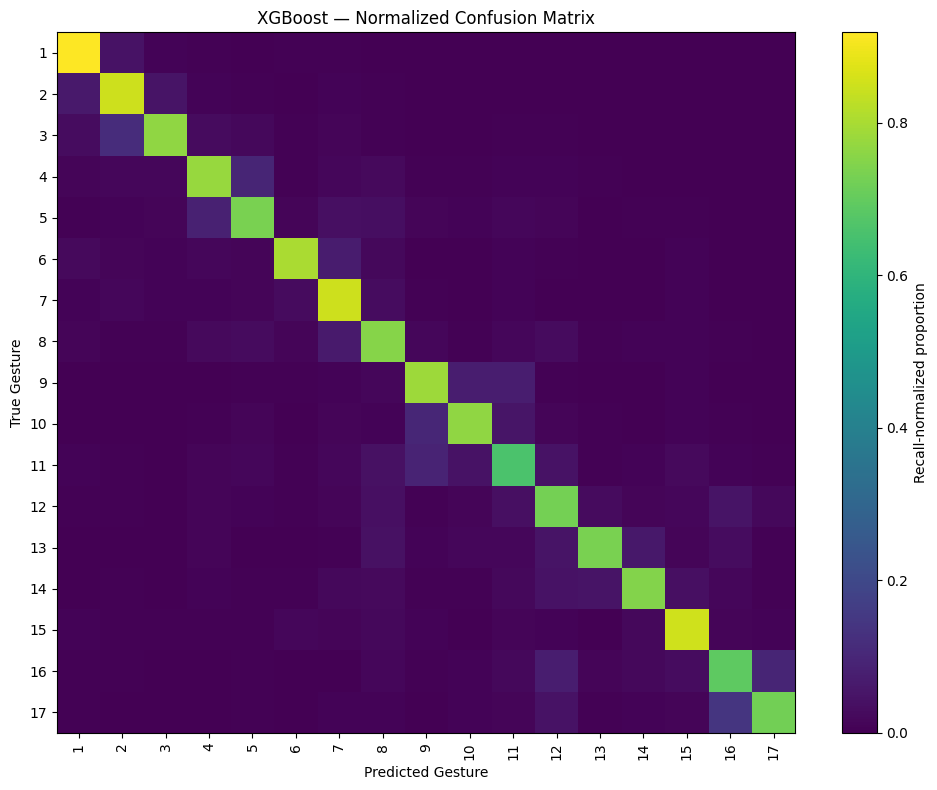

Reading: The diagonal represents correct predictions. Gesture 1 has the highest recall, while gesture 11 has the lowest recall and is the main class to improve.

Per-class evaluation and confusion matrix: PASSED


In [15]:
best_pred = baseline_predictions[
    best_baseline_name
]["pred"]

best_scores = baseline_predictions[
    best_baseline_name
]["score"]

(
    class_precision,
    class_recall,
    class_f1,
    class_support,
) = precision_recall_fscore_support(
    y_test,
    best_pred,
    labels=np.arange(N_CLASSES),
    zero_division=0,
)

per_class_df = pd.DataFrame(
    {
        "Gesture": np.arange(
            1,
            N_CLASSES + 1,
        ),
        "Precision": class_precision,
        "Recall": class_recall,
        "F1-score": class_f1,
        "Support": class_support,
    }
)

display(
    per_class_df.style.format(
        {
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1-score": "{:.3f}",
            "Support": "{:,}",
        }
    )
)

cm = confusion_matrix(
    y_test,
    best_pred,
    labels=np.arange(N_CLASSES),
    normalize="true",
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm,
    aspect="auto",
)

ax.set_title(
    f"{best_baseline_name} — Normalized Confusion Matrix"
)

ax.set_xlabel(
    "Predicted Gesture"
)

ax.set_ylabel(
    "True Gesture"
)

ticks = np.arange(
    N_CLASSES
)

ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    ),
    rotation=90,
)

ax.set_yticklabels(
    np.arange(
        1,
        N_CLASSES + 1,
    )
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Recall-normalized proportion"
)

plt.tight_layout()
plt.show()

best_gesture = int(
    per_class_df.loc[
        per_class_df[
            "Recall"
        ].idxmax(),
        "Gesture",
    ]
)

weakest_gesture = int(
    per_class_df.loc[
        per_class_df[
            "Recall"
        ].idxmin(),
        "Gesture",
    ]
)

print(
    "Reading: The diagonal represents correct predictions. "
    f"Gesture {best_gesture} has the highest recall, while gesture "
    f"{weakest_gesture} has the lowest recall and is the main class to improve."
)

assert cm.shape == (
    N_CLASSES,
    N_CLASSES,
)

print(
    "\nPer-class evaluation and confusion matrix: PASSED"
)


## 16. Macro ROC and Precision–Recall Curves

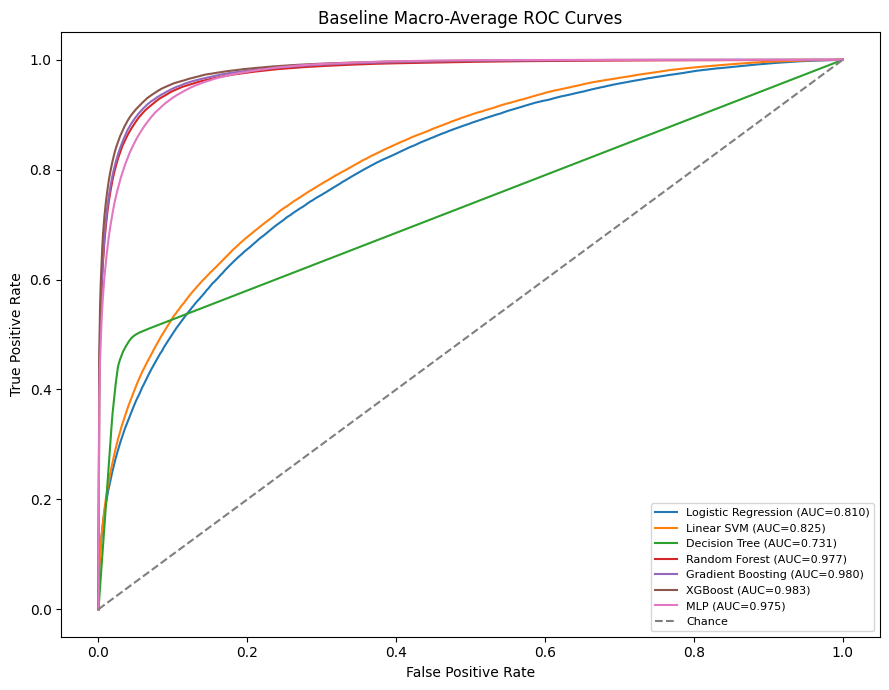

ROC reading: XGBoost has the highest macro ROC-AUC (0.983), showing the strongest overall one-vs-rest ranking ability.


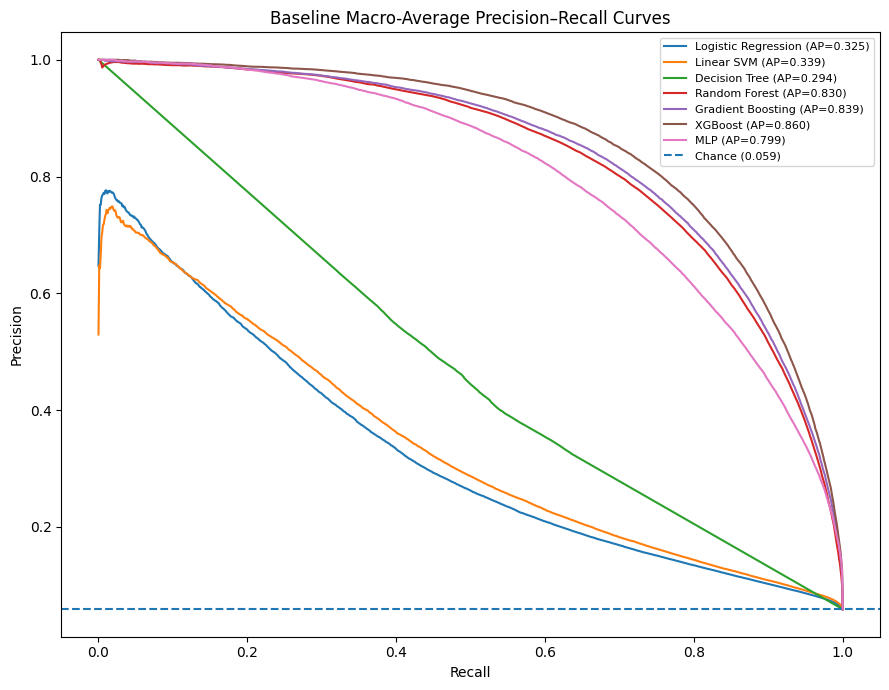

PR reading: XGBoost has the highest macro PR-AUC (0.860), indicating the best precision-recall trade-off across the 17 gestures.

ROC and PR evaluation: PASSED


In [16]:
roc_grid = np.linspace(
    0.0,
    1.0,
    1000,
)

pr_recall_grid = np.linspace(
    0.0,
    1.0,
    1000,
)


def macro_roc_curve(
    score_matrix,
):
    class_tprs = []

    for class_id in range(
        N_CLASSES
    ):
        fpr, tpr, _ = roc_curve(
            y_test_binary[
                :,
                class_id
            ],
            score_matrix[
                :,
                class_id
            ],
        )

        interpolated = np.interp(
            roc_grid,
            fpr,
            tpr,
        )

        interpolated[
            0
        ] = 0.0

        class_tprs.append(
            interpolated
        )

    macro_tpr = np.mean(
        class_tprs,
        axis=0,
    )

    macro_tpr[
        -1
    ] = 1.0

    return macro_tpr


def macro_pr_curve(
    score_matrix,
):
    class_precisions = []

    for class_id in range(
        N_CLASSES
    ):
        precision, recall, _ = precision_recall_curve(
            y_test_binary[
                :,
                class_id
            ],
            score_matrix[
                :,
                class_id
            ],
        )

        recall = recall[
            ::-1
        ]

        precision = precision[
            ::-1
        ]

        interpolated = np.interp(
            pr_recall_grid,
            recall,
            precision,
        )

        class_precisions.append(
            interpolated
        )

    return np.mean(
        class_precisions,
        axis=0,
    )


fig, ax = plt.subplots(
    figsize=(9, 7)
)

for result in baseline_results:
    model_name = result[
        "Model"
    ]

    score_matrix = baseline_predictions[
        model_name
    ]["score"]

    macro_tpr = macro_roc_curve(
        score_matrix
    )

    ax.plot(
        roc_grid,
        macro_tpr,
        label=(
            f"{model_name} "
            f"(AUC={result['ROC-AUC Macro']:.3f})"
        ),
    )

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Chance",
)

ax.set_title(
    "Baseline Macro-Average ROC Curves"
)

ax.set_xlabel(
    "False Positive Rate"
)

ax.set_ylabel(
    "True Positive Rate"
)

ax.legend(
    loc="lower right",
    fontsize=8,
)

plt.tight_layout()
plt.show()

best_roc_model = max(
    baseline_results,
    key=lambda item: item[
        "ROC-AUC Macro"
    ],
)

print(
    "ROC reading: "
    f"{best_roc_model['Model']} has the highest macro ROC-AUC "
    f"({best_roc_model['ROC-AUC Macro']:.3f}), showing the strongest "
    "overall one-vs-rest ranking ability."
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)

for result in baseline_results:
    model_name = result[
        "Model"
    ]

    score_matrix = baseline_predictions[
        model_name
    ]["score"]

    macro_precision_curve = macro_pr_curve(
        score_matrix
    )

    ax.plot(
        pr_recall_grid,
        macro_precision_curve,
        label=(
            f"{model_name} "
            f"(AP={result['PR-AUC Macro']:.3f})"
        ),
    )

chance_pr = (
    1.0 / N_CLASSES
)

ax.axhline(
    chance_pr,
    linestyle="--",
    label=(
        f"Chance ({chance_pr:.3f})"
    ),
)

ax.set_title(
    "Baseline Macro-Average Precision–Recall Curves"
)

ax.set_xlabel(
    "Recall"
)

ax.set_ylabel(
    "Precision"
)

ax.legend(
    loc="upper right",
    fontsize=8,
)

plt.tight_layout()
plt.show()

best_pr_model = max(
    baseline_results,
    key=lambda item: item[
        "PR-AUC Macro"
    ],
)

print(
    "PR reading: "
    f"{best_pr_model['Model']} has the highest macro PR-AUC "
    f"({best_pr_model['PR-AUC Macro']:.3f}), indicating the best "
    "precision-recall trade-off across the 17 gestures."
)

print(
    "\nROC and PR evaluation: PASSED"
)
